# Lab 06: Frequency-Domain Restoration and Notch Filtering
This notebook provides complete, question-wise solutions for all Lab 06 tasks with detailed comments and visual analysis.

## What This Notebook Covers
1. Add periodic noise, apply Butterworth band-pass filtering to extract the noise, and plot its PDF.
2. Corrupt an image with impulse noise and apply:
   - Ideal notch reject filter
   - Gaussian notch reject filter
   - Butterworth notch reject filter
3. Add different noise types to a degraded (blurred) image and restore using:
   - Inverse filter
   - Wiener filter

All processing is performed on grayscale images normalized to [0, 1].

In [5]:
# ================================
# Common imports and helper tools
# ================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy import signal
from skimage import data, img_as_float
from skimage.util import random_noise
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

np.random.seed(7)

def to_float01(img):
    arr = np.asarray(img, dtype=np.float64)
    if arr.max() > 1.0:
        arr = arr / 255.0
    return np.clip(arr, 0.0, 1.0)

def calc_metrics(reference, test):
    ref = to_float01(reference)
    tst = to_float01(test)
    psnr = peak_signal_noise_ratio(ref, tst, data_range=1.0)
    ssim = structural_similarity(ref, tst, data_range=1.0)
    return psnr, ssim

def show_images(images, titles, cols=3, cmap="gray", figsize=(15, 8)):
    rows = int(np.ceil(len(images) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()

    for ax, image, title in zip(axes, images, titles):
        ax.imshow(image, cmap=cmap, vmin=0, vmax=1)
        ax.set_title(title, fontsize=10)
        ax.axis("off")

    for ax in axes[len(images):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

def add_periodic_noise(img, amp=0.22, fx=18, fy=18):
    image = to_float01(img)
    m, n = image.shape
    y, x = np.indices((m, n))
    periodic = 0.5 * amp * np.sin(2 * np.pi * fx * x / n) + 0.5 * amp * np.sin(2 * np.pi * fy * y / m)
    noisy = np.clip(image + periodic, 0.0, 1.0)
    return noisy, periodic

def butterworth_band_reject(shape, D0, W, order=2):
    p, q = shape
    u = np.arange(p) - p / 2
    v = np.arange(q) - q / 2
    vv, uu = np.meshgrid(v, u)
    D = np.sqrt(uu ** 2 + vv ** 2)

    eps = 1e-8
    denominator = np.abs(D ** 2 - D0 ** 2) + eps
    return 1.0 / (1.0 + ((D * W) / denominator) ** (2 * order))

def butterworth_bandpass(shape, D0, W, order=2):
    return 1.0 - butterworth_band_reject(shape, D0=D0, W=W, order=order)

def apply_frequency_filter(img, H):
    image = to_float01(img)
    F = np.fft.fftshift(np.fft.fft2(image))
    G = F * H
    filtered = np.real(np.fft.ifft2(np.fft.ifftshift(G)))
    return np.clip(filtered, 0.0, 1.0), F, G

def notch_distance_grids(shape, uk, vk):
    p, q = shape
    u = np.arange(p) - p / 2
    v = np.arange(q) - q / 2
    vv, uu = np.meshgrid(v, u)
    Dk = np.sqrt((uu - uk) ** 2 + (vv - vk) ** 2)
    Dmk = np.sqrt((uu + uk) ** 2 + (vv + vk) ** 2)
    return Dk, Dmk

def ideal_notch_reject(shape, notch_centers, D0=8):
    H = np.ones(shape, dtype=np.float64)
    for uk, vk in notch_centers:
        Dk, Dmk = notch_distance_grids(shape, uk, vk)
        H[(Dk <= D0) | (Dmk <= D0)] = 0.0
    return H

def gaussian_notch_reject(shape, notch_centers, D0=8):
    H = np.ones(shape, dtype=np.float64)
    for uk, vk in notch_centers:
        Dk, Dmk = notch_distance_grids(shape, uk, vk)
        H *= (1.0 - np.exp(-(Dk ** 2) / (2 * D0 ** 2)))
        H *= (1.0 - np.exp(-(Dmk ** 2) / (2 * D0 ** 2)))
    return np.clip(H, 0.0, 1.0)

def butterworth_notch_reject(shape, notch_centers, D0=8, order=2):
    H = np.ones(shape, dtype=np.float64)
    eps = 1e-8
    for uk, vk in notch_centers:
        Dk, Dmk = notch_distance_grids(shape, uk, vk)
        H *= 1.0 / (1.0 + (D0 / (Dk + eps)) ** (2 * order))
        H *= 1.0 / (1.0 + (D0 / (Dmk + eps)) ** (2 * order))
    return np.clip(H, 0.0, 1.0)

def gaussian_kernel(size=15, sigma=2.5):
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx ** 2 + yy ** 2) / (2 * sigma ** 2))
    kernel /= np.sum(kernel)
    return kernel

def psf_to_otf(psf, shape):
    ph, pw = psf.shape
    padded = np.zeros(shape, dtype=np.float64)
    padded[:ph, :pw] = psf
    padded = np.roll(padded, -ph // 2, axis=0)
    padded = np.roll(padded, -pw // 2, axis=1)
    return np.fft.fft2(padded)

def inverse_filter(degraded, H, eps=1e-3):
    G = np.fft.fft2(to_float01(degraded))
    F_hat = np.zeros_like(G, dtype=np.complex128)
    mask = np.abs(H) >= eps
    F_hat[mask] = G[mask] / H[mask]
    restored = np.real(np.fft.ifft2(F_hat))
    return np.clip(restored, 0.0, 1.0)

def wiener_filter(degraded, H, K=0.005):
    G = np.fft.fft2(to_float01(degraded))
    F_hat = (np.conj(H) / (np.abs(H) ** 2 + K)) * G
    restored = np.real(np.fft.ifft2(F_hat))
    return np.clip(restored, 0.0, 1.0)

print("Lab 06 helper functions loaded successfully.")

Lab 06 helper functions loaded successfully.


## Question 1: Periodic Noise Extraction Using Butterworth Band-Pass Filter
**Task:**
- Add periodic noise to an image.
- Apply Butterworth band-pass filter to extract the periodic noise component.
- Show extracted noise and its Probability Density Function (PDF).

**Approach:**
- Create sinusoidal periodic corruption with known frequencies.
- Build a Butterworth band-pass mask around the corresponding frequency radius.
- Use inverse FFT to recover the noise component.

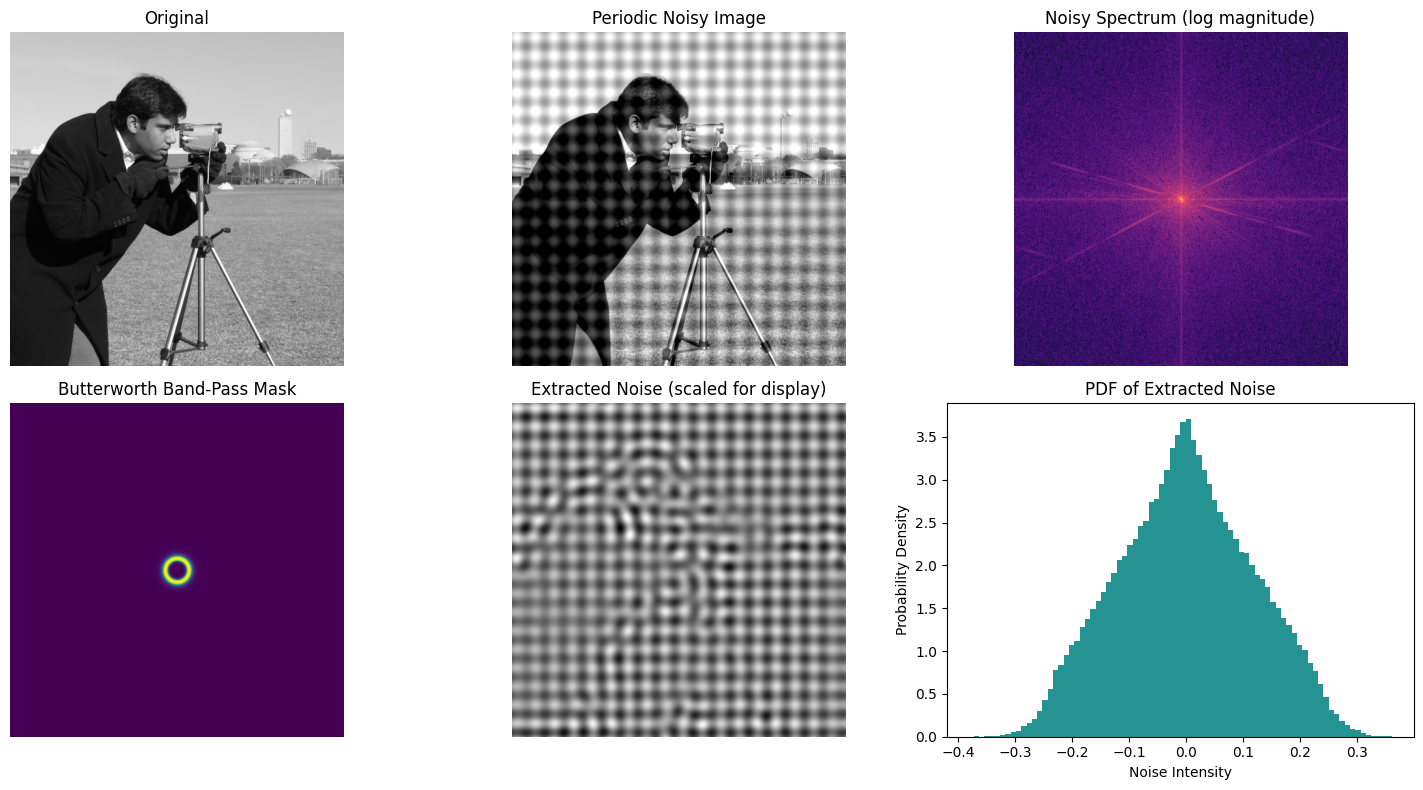

Q1 completed: extracted periodic noise and displayed its PDF.


In [7]:
# Q1 Solution: Periodic noise extraction with Butterworth band-pass filter
img_q1 = to_float01(img_as_float(data.camera()))
noisy_q1, true_periodic_q1 = add_periodic_noise(img_q1, amp=0.24, fx=18, fy=18)

# Build band-pass filter around periodic frequency radius
D0, W, n_order = 18, 8, 2
H_bp = butterworth_bandpass(img_q1.shape, D0=D0, W=W, order=n_order)

# Extract noise in frequency domain (do not clip to preserve signed values)
F_noisy_q1 = np.fft.fftshift(np.fft.fft2(noisy_q1))
G_noise_q1 = F_noisy_q1 * H_bp
extracted_noise_q1 = np.real(np.fft.ifft2(np.fft.ifftshift(G_noise_q1)))

# Scale extracted noise only for visualization
noise_vis_q1 = (extracted_noise_q1 - extracted_noise_q1.min()) / (np.ptp(extracted_noise_q1) + 1e-12)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes[0, 0].imshow(img_q1, cmap="gray", vmin=0, vmax=1)
axes[0, 0].set_title("Original")
axes[0, 1].imshow(noisy_q1, cmap="gray", vmin=0, vmax=1)
axes[0, 1].set_title("Periodic Noisy Image")
axes[0, 2].imshow(np.log1p(np.abs(F_noisy_q1)), cmap="magma")
axes[0, 2].set_title("Noisy Spectrum (log magnitude)")

axes[1, 0].imshow(H_bp, cmap="viridis")
axes[1, 0].set_title("Butterworth Band-Pass Mask")
axes[1, 1].imshow(noise_vis_q1, cmap="gray")
axes[1, 1].set_title("Extracted Noise (scaled for display)")
axes[1, 2].hist(extracted_noise_q1.ravel(), bins=80, density=True, color="teal", alpha=0.85)
axes[1, 2].set_title("PDF of Extracted Noise")
axes[1, 2].set_xlabel("Noise Intensity")
axes[1, 2].set_ylabel("Probability Density")

for ax in [axes[0, 0], axes[0, 1], axes[0, 2], axes[1, 0], axes[1, 1]]:
    ax.axis("off")
plt.tight_layout()
plt.show()

print("Q1 completed: extracted periodic noise and displayed its PDF.")

## Question 2: Notch Reject Filters on Impulse-Noise-Corrupted Image
**Task:** For a grayscale image corrupted by impulse noise, apply:
1. Ideal notch reject filter
2. Gaussian notch reject filter
3. Butterworth notch reject filter

**Approach:**
- Add salt-and-pepper (impulse) noise.
- Build each notch reject mask using symmetric notch pairs in frequency domain.
- Apply filters and compare PSNR/SSIM of restored results.

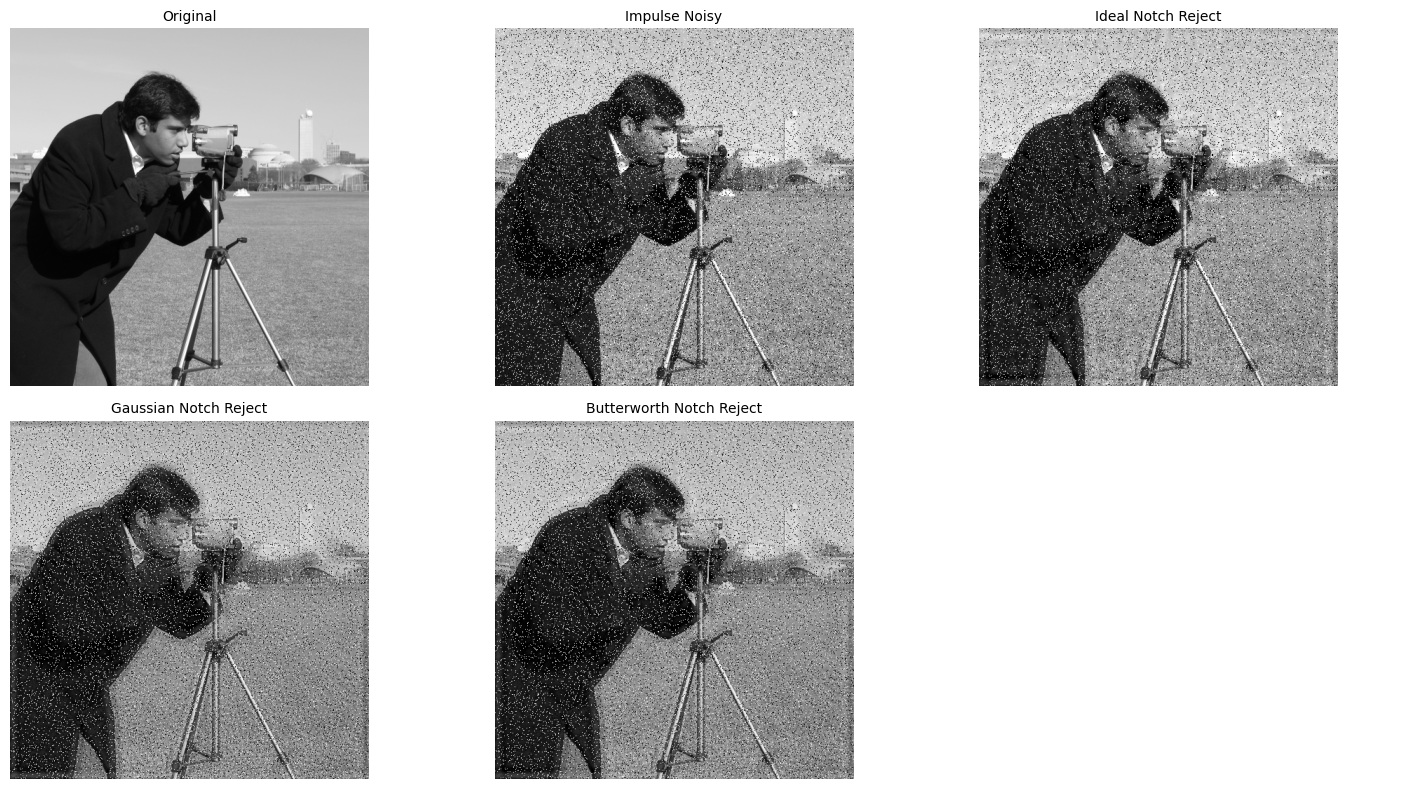

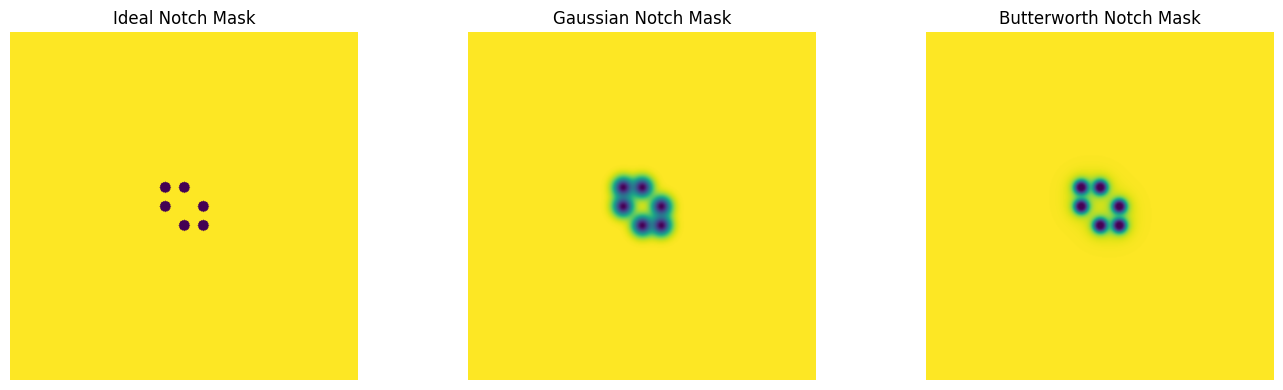

Q2: Notch Filter Quality Comparison


,Method,PSNR (dB),SSIM
0,Ideal Notch Reject,14.059,0.1576
1,Noisy (Impulse),13.998,0.1603
2,Butterworth Notch Reject,13.935,0.1568
3,Gaussian Notch Reject,13.872,0.1545


In [8]:
# Q2 Solution: Ideal, Gaussian, and Butterworth notch reject filters
img_q2 = to_float01(img_as_float(data.camera()))
impulse_noisy_q2 = to_float01(random_noise(img_q2, mode="s&p", amount=0.12))

# Symmetric notch centers (u_k, v_k) around FFT origin
notch_centers = [(0, 28), (28, 0), (28, 28)]

H_ideal = ideal_notch_reject(img_q2.shape, notch_centers=notch_centers, D0=8)
H_gaussian = gaussian_notch_reject(img_q2.shape, notch_centers=notch_centers, D0=10)
H_butter = butterworth_notch_reject(img_q2.shape, notch_centers=notch_centers, D0=10, order=2)

ideal_restored_q2, _, _ = apply_frequency_filter(impulse_noisy_q2, H_ideal)
gaussian_restored_q2, _, _ = apply_frequency_filter(impulse_noisy_q2, H_gaussian)
butter_restored_q2, _, _ = apply_frequency_filter(impulse_noisy_q2, H_butter)

methods_q2 = {
    "Noisy (Impulse)": impulse_noisy_q2,
    "Ideal Notch Reject": ideal_restored_q2,
    "Gaussian Notch Reject": gaussian_restored_q2,
    "Butterworth Notch Reject": butter_restored_q2,
}

rows_q2 = []
for name, out in methods_q2.items():
    psnr, ssim = calc_metrics(img_q2, out)
    rows_q2.append({"Method": name, "PSNR (dB)": round(psnr, 3), "SSIM": round(ssim, 4)})

show_images(
    [img_q2, impulse_noisy_q2, ideal_restored_q2, gaussian_restored_q2, butter_restored_q2],
    [
        "Original",
        "Impulse Noisy",
        "Ideal Notch Reject",
        "Gaussian Notch Reject",
        "Butterworth Notch Reject",
    ],
    cols=3,
    figsize=(15, 8),
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(H_ideal, cmap="viridis")
axes[0].set_title("Ideal Notch Mask")
axes[1].imshow(H_gaussian, cmap="viridis")
axes[1].set_title("Gaussian Notch Mask")
axes[2].imshow(H_butter, cmap="viridis")
axes[2].set_title("Butterworth Notch Mask")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

df_q2 = pd.DataFrame(rows_q2).sort_values(by="PSNR (dB)", ascending=False).reset_index(drop=True)
print("Q2: Notch Filter Quality Comparison")
display(df_q2)

## Question 3: Inverse Filter and Wiener Filter for Image Restoration
**Task:** Add different noise types to a grayscale image and implement restoration using:
1. Inverse filter
2. Wiener filter

**Approach:**
- First degrade image by blur (known PSF).
- Add multiple noise models to the blurred image.
- Restore each degraded case using inverse and Wiener filtering.
- Compare quality with PSNR/SSIM.

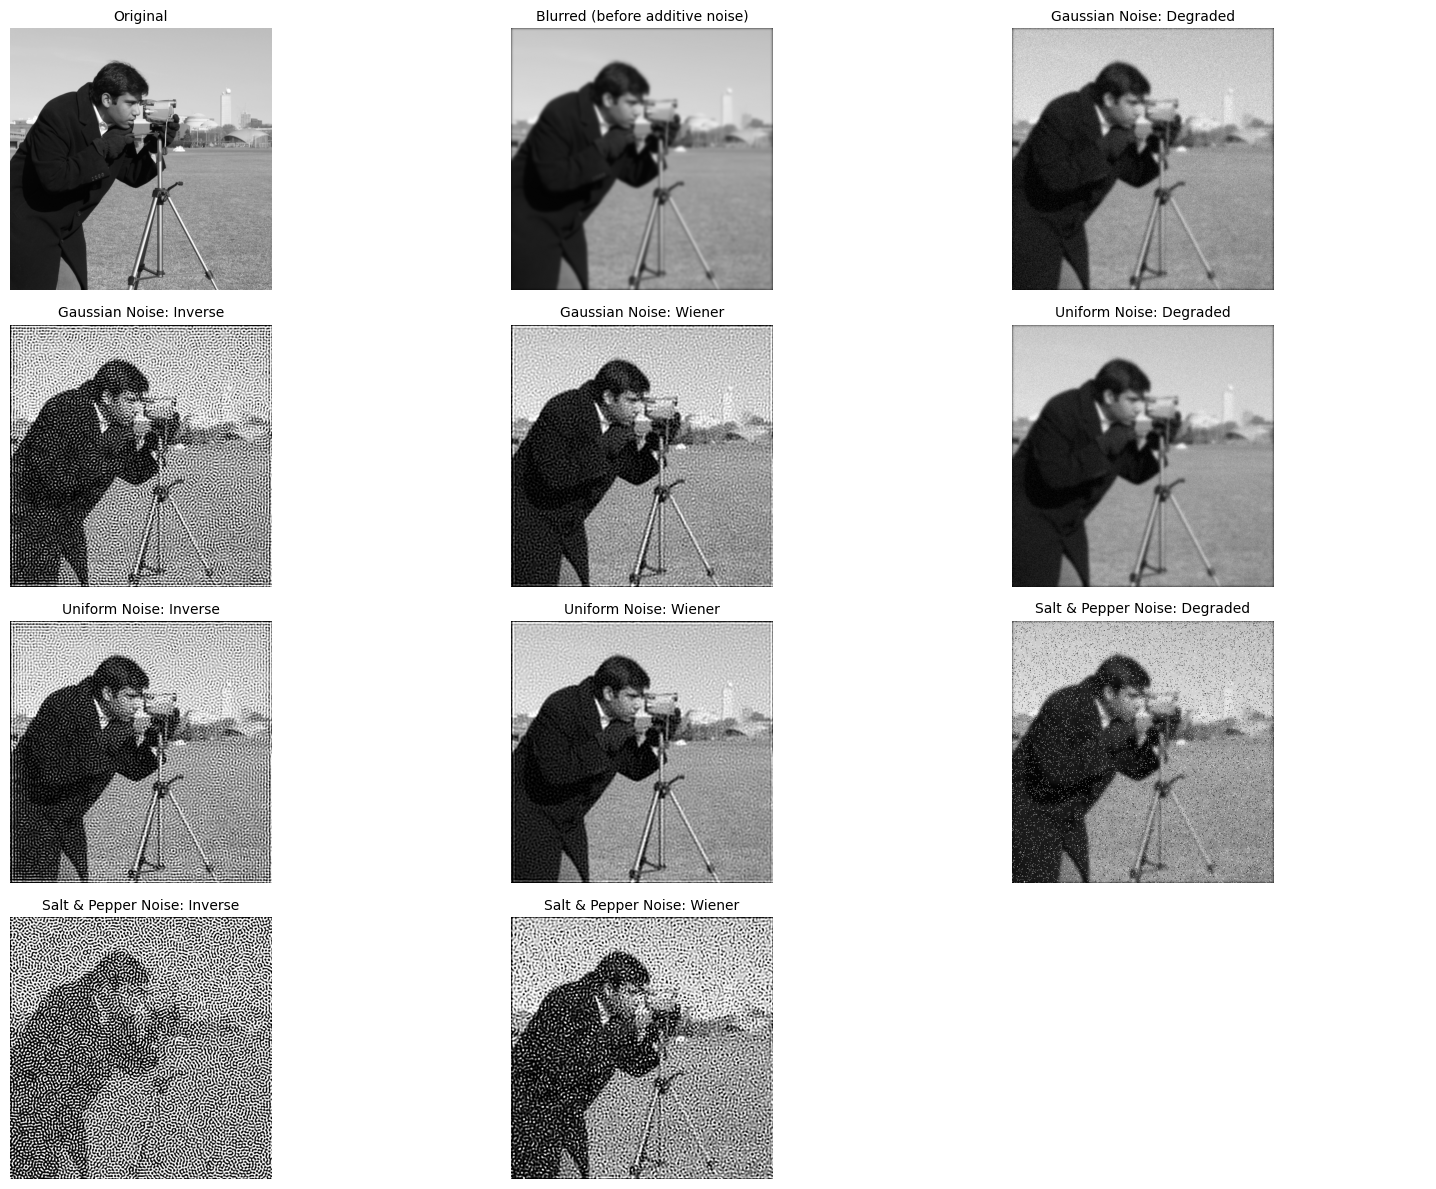

Q3: Inverse vs Wiener Filter Performance


,Noise Type,Stage,PSNR (dB),SSIM
0,Gaussian Noise,Degraded,22.158,0.3295
1,Gaussian Noise,Wiener Filter,19.184,0.2562
2,Gaussian Noise,Inverse Filter,12.166,0.0665
3,Salt & Pepper Noise,Degraded,15.114,0.1237
4,Salt & Pepper Noise,Wiener Filter,12.299,0.0673
5,Salt & Pepper Noise,Inverse Filter,6.861,0.0145
6,Uniform Noise,Degraded,23.070,0.4565
7,Uniform Noise,Wiener Filter,20.306,0.3689
8,Uniform Noise,Inverse Filter,14.260,0.1056


In [9]:
# Q3 Solution: Inverse and Wiener restoration under different noise models
img_q3 = to_float01(img_as_float(data.camera()))

# Step 1: Apply known blur degradation
psf_q3 = gaussian_kernel(size=15, sigma=2.5)
blurred_q3 = np.clip(signal.fftconvolve(img_q3, psf_q3, mode="same"), 0.0, 1.0)
H_q3 = psf_to_otf(psf_q3, img_q3.shape)

# Step 2: Add different noise models to blurred image
degraded_cases_q3 = {
    "Gaussian Noise": to_float01(random_noise(blurred_q3, mode="gaussian", var=0.002)),
    "Uniform Noise": np.clip(blurred_q3 + np.random.uniform(-0.05, 0.05, size=blurred_q3.shape), 0.0, 1.0),
    "Salt & Pepper Noise": to_float01(random_noise(blurred_q3, mode="s&p", amount=0.08)),
}

rows_q3 = []
gallery_images = [img_q3, blurred_q3]
gallery_titles = ["Original", "Blurred (before additive noise)"]

for noise_name, degraded in degraded_cases_q3.items():
    restored_inverse = inverse_filter(degraded, H_q3, eps=0.02)
    restored_wiener = wiener_filter(degraded, H_q3, K=0.005)

    # Metrics against original clean image
    psnr_deg, ssim_deg = calc_metrics(img_q3, degraded)
    psnr_inv, ssim_inv = calc_metrics(img_q3, restored_inverse)
    psnr_wie, ssim_wie = calc_metrics(img_q3, restored_wiener)

    rows_q3.extend([
        {"Noise Type": noise_name, "Stage": "Degraded", "PSNR (dB)": round(psnr_deg, 3), "SSIM": round(ssim_deg, 4)},
        {"Noise Type": noise_name, "Stage": "Inverse Filter", "PSNR (dB)": round(psnr_inv, 3), "SSIM": round(ssim_inv, 4)},
        {"Noise Type": noise_name, "Stage": "Wiener Filter", "PSNR (dB)": round(psnr_wie, 3), "SSIM": round(ssim_wie, 4)},
    ])

    gallery_images.extend([degraded, restored_inverse, restored_wiener])
    gallery_titles.extend([
        f"{noise_name}: Degraded",
        f"{noise_name}: Inverse",
        f"{noise_name}: Wiener",
    ])

show_images(gallery_images, gallery_titles, cols=3, figsize=(16, 12))

df_q3 = pd.DataFrame(rows_q3)
print("Q3: Inverse vs Wiener Filter Performance")
display(df_q3.sort_values(by=["Noise Type", "PSNR (dB)"], ascending=[True, False]).reset_index(drop=True))